In [1]:
"""
CHO Bioprocess Optimization Toolkit - Integrated Version
========================================================
Key Features:
1. Supports both the real `insilicho` simulator and a fallback mechanistic simulator
2. Multiple Design of Experiments (DoE) strategies: LHS, CCD, Space-Filling, Factorial
3. Optional adaptive optimization
4. Batch management for up to 12 bioreactors
5. Response surface modeling: quadratic regression and Gaussian process
6. Comprehensive visualization utilities

Installation:
pip install insilicho numpy pandas matplotlib seaborn scikit-learn scipy
"""
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import differential_evolution
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Try to import the insilicho package
try:
    from insilicho import run
    INSILICHO_AVAILABLE = True
    print("insilicho package successfully imported.")
except ImportError:
    INSILICHO_AVAILABLE = False
    print("insilicho package not found. Using the fallback simulator instead.")
    print(" To install insilicho, run: pip install insilicho")


insilicho package successfully imported.


In [2]:
# ==================== Simulator ====================
class CHOSimulator:
    """CHO cell culture simulator supporting both the real insilicho model and a backup mechanistic simulator."""
    
    def __init__(self, use_insilicho=True):
        """
        Parameters
        ----------
        use_insilicho : bool
            Whether to use the real insilicho simulator (if installed).
        """
        self.use_insilicho = use_insilicho and INSILICHO_AVAILABLE

        if self.use_insilicho:
            print("Using the real insilicho simulator.")
        else:
            print("Using the backup mechanistic simulator.")
    
    def glc_g_to_mmol(self, g_per_L):
        """Convert glucose concentration from g/L to mmol/L (MW = 180.16 g/mol)."""
        return (g_per_L / 180.16) * 1000
    
    def run_experiment(self, initial_glucose, feed_glucose, temperature, seed=None):
        """
        Run a single CHO culture experiment.

        Parameters
        ----------
        initial_glucose : float
            Initial glucose concentration (g/L), range 3–10.
        feed_glucose : float
            Feed glucose concentration (g/L), range 20–100.
        temperature : float
            Temperature (°C), range 33–38.
        seed : int or None
            Random seed for reproducibility.

        Returns
        -------
        tuple
            (final_mab, final_vcd) — final mAb titer (mg/L) and viable cell density (million cells/mL).
        """
        if self.use_insilicho:
            return self._run_insilicho(initial_glucose, feed_glucose, temperature, seed)
        else:
            return self._run_backup_simulator(initial_glucose, feed_glucose, temperature, seed)
    
    def _run_insilicho(self, init_glc, feed_glc, temp, seed):
        """Run the real insilicho CHO simulator."""
        
        def T(time):
            return temp
        
        def F(time):
            return 0.003  # L/hr (constant feed rate)
        
        model = run.GrowCHO(
            config={
                "parameters": {
                    "Cglc_feed": f"{self.glc_g_to_mmol(feed_glc)} mmol/L",
                },
                "initial_conditions": {
                    "Cglc": f"{self.glc_g_to_mmol(init_glc)} mmol/L",
                    "V": "100 mL",
                }
            },
            feed_fn=F,
            temp_fn=T,
            random_seed=seed if seed else 42,
        )
        
        result = model.execute(plot=False)
        
        final_mab = result["Cmab"][-1]  # mg/L
        final_vcd = result["Xv"][-1]    # million cells/mL
        
        return final_mab, final_vcd
    
    def _run_backup_simulator(self, init_glc, feed_glc, temp, seed):
        """
        Backup simulator based on mechanistic assumptions derived from typical CHO cell responses in literature.
        """
        if seed is not None:
            np.random.seed(seed)
        
        ig = (init_glc - 3) / (10 - 3)
        fg = (feed_glc - 20) / (100 - 20)
        t = (temp - 33) / (38 - 33)
        
        # Temperature effect: optimal around 36.2 °C
        temp_eff = np.exp(-0.5 * ((temp - 36.2) / 0.3) ** 2)
        
        # Initial glucose effect: optimal around 6.5 g/L
        ig_eff = np.exp(-0.5 * ((init_glc - 6.5) / 1.5) ** 2)
        
        # Feed glucose effect: saturating kinetics + high concentration inhibition
        fg_sat = 1 - np.exp(-3 * fg)
        fg_penalty = 0.2 * max(0, (fg - 0.85)) ** 2
        
        # Compute VCD (viable cell density)
        vcd = (6 + 15 * (0.5 * temp_eff + 0.3 * ig_eff + 0.2 * fg_sat) 
               - 8 * fg_penalty)
        vcd = np.clip(vcd, 4, 22)
        
        # Compute mAb titer
        qp = 0.9 + 0.6 * temp_eff + 0.4 * ig_eff + 0.5 * fg_sat - 0.5 * fg_penalty
        mab = 200 + 150 * vcd * qp
        
        # Add ~5% experimental noise
        noise = 0.05
        mab *= np.random.normal(1, noise)
        vcd *= np.random.normal(1, noise)
        
        return max(0, mab), max(0, vcd)


In [3]:
# ==================== Design of Experiments (DoE) Generator ====================
class DOEDesigner:
    """Experimental design generator supporting multiple DoE strategies."""
    
    def __init__(self, param_ranges):
        """
        Parameters
        ----------
        param_ranges : dict
            A dictionary specifying parameter ranges, e.g. {'param_name': (min, max)}.
        """
        self.param_ranges = param_ranges
        self.param_names = list(param_ranges.keys())
        self.n_factors = len(param_ranges)
    
    def latin_hypercube(self, n_samples):
        """Latin Hypercube Sampling (LHS) - optimal space-filling design."""
        n_dims = self.n_factors
        
        # Generate stratified grid
        segments = np.linspace(0, 1, n_samples + 1)
        centers = (segments[:-1] + segments[1:]) / 2.0
        
        # Random permutation for each dimension
        design = np.zeros((n_samples, n_dims))
        for j in range(n_dims):
            perm = np.random.permutation(n_samples)
            design[:, j] = centers[perm]
        
        # Add small random jitter within each cell
        design += np.random.rand(n_samples, n_dims) / n_samples
        
        # Scale to actual parameter bounds
        return self._scale_to_bounds(design)
    
    def central_composite(self):
        """Central Composite Design (CCD) - standard in Response Surface Methodology."""
        n = self.n_factors
        
        # 1. Factorial points (2^k cube vertices)
        factorial = []
        for i in range(2 ** n):
            point = [(i >> j) & 1 for j in range(n)]
            factorial.append(point)
        factorial = np.array(factorial) * 2 - 1  # Convert to -1, +1 levels
        
        # 2. Axial (star) points (2k)
        alpha = np.sqrt(n)  # rotatable design
        axial = []
        for i in range(n):
            pos = [0] * n
            neg = [0] * n
            pos[i] = alpha
            neg[i] = -alpha
            axial.append(pos)
            axial.append(neg)
        axial = np.array(axial)
        
        # 3. Center points (replicates for pure error estimation)
        center = np.zeros((3, n))
        
        # Combine all points
        design_coded = np.vstack([factorial, axial, center])
        
        # Convert coded values to real-world parameter scales
        design_real = np.zeros_like(design_coded)
        for i, param in enumerate(self.param_names):
            min_val, max_val = self.param_ranges[param]
            center_val = (max_val + min_val) / 2
            half_range = (max_val - min_val) / 2
            design_real[:, i] = center_val + (design_coded[:, i] / alpha) * half_range
        
        return pd.DataFrame(design_real, columns=self.param_names)
    
    def full_factorial(self, levels=3):
        """Full factorial design."""
        level_arrays = []
        for param in self.param_names:
            min_val, max_val = self.param_ranges[param]
            level_arrays.append(np.linspace(min_val, max_val, levels))
        
        grids = np.meshgrid(*level_arrays, indexing='ij')
        design = np.column_stack([g.ravel() for g in grids])
        
        return pd.DataFrame(design, columns=self.param_names)
    
    def space_filling(self, n_samples):
        """Improved space-filling design based on Latin Hypercube."""
        return self.latin_hypercube(n_samples)
    
    def _scale_to_bounds(self, design_unit):
        """Scale normalized [0,1] design to actual parameter bounds."""
        design_real = np.zeros_like(design_unit)
        for i, param in enumerate(self.param_names):
            min_val, max_val = self.param_ranges[param]
            design_real[:, i] = min_val + design_unit[:, i] * (max_val - min_val)
        
        return pd.DataFrame(design_real, columns=self.param_names)


In [4]:
# ==================== Response Surface Model ====================
class ResponseSurfaceModel:
    """Response Surface Model supporting both quadratic polynomial and Gaussian process regression."""
    
    def __init__(self, model_type='quadratic'):
        """
        Parameters
        ----------
        model_type : str
            Type of model to use. Options are:
            - 'quadratic' for a second-order polynomial model
            - 'gaussian_process' for a non-parametric GP model
        """
        self.model_type = model_type
        self.scaler = StandardScaler()
        
        if model_type == 'quadratic':
            self.poly = PolynomialFeatures(degree=2, include_bias=False)
            self.model = LinearRegression()
        elif model_type == 'gaussian_process':
            kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
            self.model = GaussianProcessRegressor(
                kernel=kernel,
                alpha=0.01,
                n_restarts_optimizer=10,
                normalize_y=True
            )
        else:
            raise ValueError(f"Unknown model type: {model_type}")
        
        self.X_train = None
        self.y_train = None
        self.is_fitted = False
    
    def fit(self, X, y):
        """Fit the response surface model to data."""
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        X_scaled = self.scaler.fit_transform(X)
        
        if self.model_type == 'quadratic':
            X_poly = self.poly.fit_transform(X_scaled)
            self.model.fit(X_poly, y)
        else:
            self.model.fit(X_scaled, y)
        
        self.is_fitted = True
        
        # Evaluate model performance
        y_pred = self.predict(X)
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        
        print(f"  Model type: {self.model_type}")
        print(f"  R² = {r2:.4f}")
        print(f"  RMSE = {rmse:.2f} mg/L")
        
        return self
    
    def predict(self, X, return_std=False):
        """Predict response values (optionally with uncertainty for GP)."""
        if not self.is_fitted:
            raise ValueError("Model is not fitted yet.")
        
        X_scaled = self.scaler.transform(X)
        
        if self.model_type == 'quadratic':
            X_poly = self.poly.transform(X_scaled)
            y_pred = self.model.predict(X_poly)
            if return_std:
                # Quadratic model does not provide uncertainty
                return y_pred, np.zeros_like(y_pred)
            return y_pred
        else:
            if return_std:
                return self.model.predict(X_scaled, return_std=True)
            return self.model.predict(X_scaled)
    
    def optimize(self, param_ranges):
        """Find the optimal parameter combination that maximizes the predicted response."""
        param_names = list(param_ranges.keys())
        bounds = [param_ranges[name] for name in param_names]
        
        def objective(x):
            X = np.array([x])
            pred = self.predict(X)
            return -pred[0]  # maximize
        
        result = differential_evolution(
            objective,
            bounds,
            seed=42,
            maxiter=1000,
            popsize=15
        )
        
        optimal_params = result.x
        optimal_value = -result.fun
        
        return optimal_params, optimal_value


In [6]:
# ==================== Main Optimizer Class ====================
class CHOProcessOptimizer:
    """Main controller for the CHO bioprocess optimization workflow."""
    
    def __init__(self, n_runs, n_bioreactors, use_insilicho=True):
        """
        Initializes the optimizer with the simulator and a data storage structure.
        
        Parameters
        ----------
        n_runs : int
            Total number of experiments to perform.
        n_bioreactors : int
            Number of parallel bioreactors (batches) available per DoE round.
        use_insilicho : bool
            Whether to use the insilicho simulator.
        """
        self.param_ranges = {
            'initial_glucose': (3.0, 10.0),  # g/L
            'feed_glucose': (20.0, 100.0),   # g/L
            'temperature': (33.0, 38.0)      # °C
        }
        self.param_names = list(self.param_ranges.keys())
        self.n_runs = n_runs
        self.n_bioreactors = n_bioreactors
        
        # Initialize components
        self.simulator = CHOSimulator(use_insilicho=use_insilicho)
        self.doe_designer = DOEDesigner(self.param_ranges)
        self.results = pd.DataFrame(columns=self.param_names + ['mab', 'vcd'])
    
    def run_experiments(self, X_df, verbose=False):
        """Executes the experiments defined in the DoE."""
        
        new_results = []
        n_experiments = len(X_df)
        
        for i, row in X_df.iterrows():
            if verbose:
                print(f"  Running Experiment {i+1}/{n_experiments}...")
            
            # Run simulation
            mab, vcd = self.simulator.run_experiment(
                initial_glucose=row['initial_glucose'],
                feed_glucose=row['feed_glucose'],
                temperature=row['temperature'],
                seed=i # Use experiment index as seed for some variety/reproducibility
            )
            
            # Store results
            result_row = row.copy()
            result_row['mab'] = mab
            result_row['vcd'] = vcd
            new_results.append(result_row)

        return pd.DataFrame(new_results, columns=self.param_names + ['mab', 'vcd'])
    
    def run_optimization(self, strategy, model_type, adaptive=False, verbose=False):
        """
        Runs the full optimization workflow.
        
        (This is a simplified, non-adaptive version for the first round)
        """
        
        # 1. Design of Experiments (DoE)
        if verbose:
            print(f"\n[1/3] Designing Experiments (Strategy: {strategy.upper()})...")
        
        if strategy == 'lhs' or strategy == 'space_filling':
            X_doe = self.doe_designer.latin_hypercube(n_samples=self.n_runs)
        elif strategy == 'ccd':
            X_doe = self.doe_designer.central_composite()
        elif strategy == 'factorial':
            X_doe = self.doe_designer.full_factorial(levels=3)
        else:
            raise ValueError(f"Unknown DoE strategy: {strategy}")

        if verbose:
            print(f"  Designed {len(X_doe)} experiments.")
            
        # 2. Run Experiments
        if verbose:
            print(f"\n[2/3] Running Experiments (using {self.n_bioreactors} bioreactors in parallel rounds)...")
        
        # In a real batch process, you would split X_doe into rounds based on n_bioreactors
        # Here we run all experiments sequentially for simplicity in the simulation
        new_results_df = self.run_experiments(X_doe, verbose)
        self.results = pd.concat([self.results, new_results_df], ignore_index=True)
        
        if verbose:
            best_mab = self.results['mab'].max()
            print(f"  Experiments completed. Best Titer Found: {best_mab:.2f} mg/L")

        # 3. Build Model and Optimize
        if verbose:
            print(f"\n[3/3] Building Response Surface Model ({model_type.upper()}) and Optimizing...")

        X_train = self.results[self.param_names]
        y_train = self.results['mab']
        
        model = ResponseSurfaceModel(model_type=model_type)
        model.fit(X_train, y_train)
        
        optimal_params, optimal_value = model.optimize(self.param_ranges)
        
        if verbose:
            print("\n--- Optimization Summary ---")
            print("Predicted Optimal Conditions:")
            for name, val in zip(self.param_names, optimal_params):
                print(f"  {name}: {val:.2f}")
            print(f"Predicted Maximum Titer: {optimal_value:.2f} mg/L")
            
        return self.results

In [7]:
# In[9]: 

# ----------------------------------------------------
# Step 7: Run the optimization workflow and generate results
# ----------------------------------------------------
import matplotlib.pyplot as plt
print("Matplotlib successfully imported.")

# Define total number of runs (for example, 50)
N_RUNS = 50

# Initialize the main optimizer
# Attempt to use the insilicho simulator if available
optimizer = CHOProcessOptimizer(
    n_runs=N_RUNS,
    n_bioreactors=12,
    use_insilicho=True
)

# Execute the full optimization workflow
# Recommended combination: LHS (space-filling design) + Gaussian Process (advanced response surface)
print("\n=== Starting CHO process optimization workflow ===")
final_results_df = optimizer.run_optimization(
    strategy='lhs',
    model_type='gaussian_process',
    adaptive=False,
    verbose=True
)
print("=== Optimization workflow completed ===")

# Display the first few rows of the results if needed
# display(final_results_df.head())


Matplotlib successfully imported.
Using the real insilicho simulator.

=== Starting CHO process optimization workflow ===

[1/3] Designing Experiments (Strategy: LHS)...
  Designed 50 experiments.

[2/3] Running Experiments (using 12 bioreactors in parallel rounds)...
  Running Experiment 1/50...
  Running Experiment 2/50...
  Running Experiment 3/50...
  Running Experiment 4/50...
  Running Experiment 5/50...
  Running Experiment 6/50...
  Running Experiment 7/50...
  Running Experiment 8/50...
  Running Experiment 9/50...
  Running Experiment 10/50...
  Running Experiment 11/50...
  Running Experiment 12/50...
  Running Experiment 13/50...
  Running Experiment 14/50...
  Running Experiment 15/50...
  Running Experiment 16/50...
  Running Experiment 17/50...
  Running Experiment 18/50...
  Running Experiment 19/50...
  Running Experiment 20/50...
  Running Experiment 21/50...
  Running Experiment 22/50...
  Running Experiment 23/50...
  Running Experiment 24/50...
  Running Experiment

--- Re-fitting GAUSSIAN_PROCESS model for visualization ---
  Model type: gaussian_process
  R² = 0.9998
  RMSE = 9.04 mg/L
--- Generating Response Surface (Fixed temperature = 36.5°C) ---


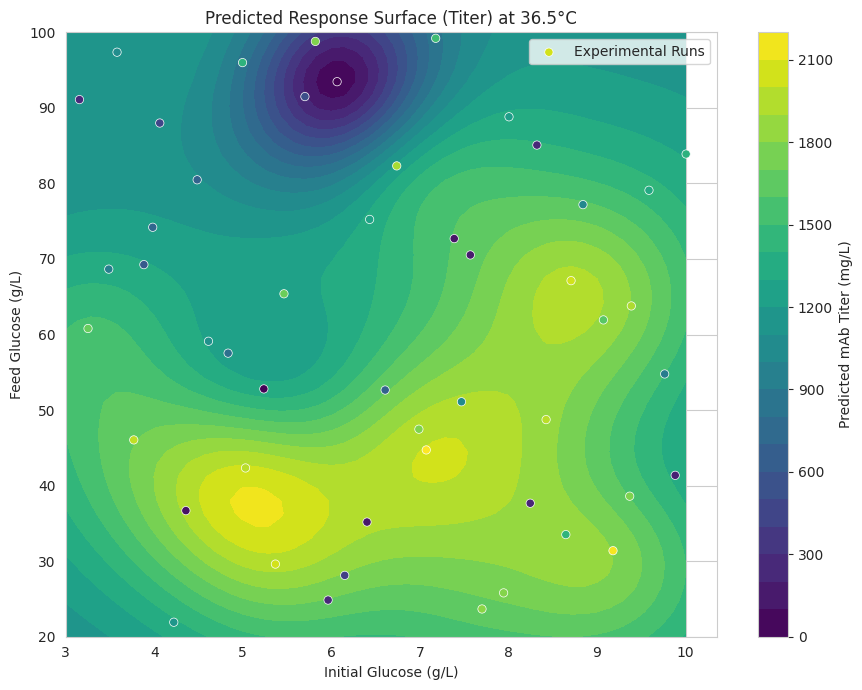


--- Visualization Complete ---


In [10]:
# Cell In[8]: Response Surface Visualization (English Version)

# Access the fitted model and parameter ranges from the optimizer instance
if 'optimizer' not in locals():
    raise NameError("The 'optimizer' object is not defined. Please ensure Cell In[5] ran successfully.")

# The fitted model is the one created in the last step of run_optimization()
# We need to re-instantiate and re-fit the model since it was created locally 
# inside the run_optimization method and not stored as an attribute.

# --- Step 1: Re-instantiate and Re-fit the Response Surface Model ---
X_train = optimizer.results[optimizer.param_names]
y_train = optimizer.results['mab']

# Ensure the correct model type is used (from your original run_optimization call)
MODEL_TYPE = 'gaussian_process' 

print(f"--- Re-fitting {MODEL_TYPE.upper()} model for visualization ---")
model = ResponseSurfaceModel(model_type=MODEL_TYPE)
model.fit(X_train, y_train)


# --- Step 2: Define Grid and Fixed Parameter ---
# Define the resolution for the contour plot
N_GRID = 50

# Define the parameter to fix and its value
FIXED_PARAM_NAME = 'temperature'
# We will fix the temperature at a mid-range optimal value, e.g., 36.5 °C
FIXED_TEMP = 36.5 

print(f"--- Generating Response Surface (Fixed {FIXED_PARAM_NAME} = {FIXED_TEMP}°C) ---")

# Define the two parameters to vary
param1_name = 'initial_glucose'
param2_name = 'feed_glucose'

# Create the grid points for the varying parameters
p1_min, p1_max = optimizer.param_ranges[param1_name]
p2_min, p2_max = optimizer.param_ranges[param2_name]

p1_space = np.linspace(p1_min, p1_max, N_GRID)
p2_space = np.linspace(p2_min, p2_max, N_GRID)

P1, P2 = np.meshgrid(p1_space, p2_space)


# --- Step 3: Predict Titer over the Grid ---
# Prepare the input DataFrame for prediction
grid_data = {
    param1_name: P1.ravel(),
    param2_name: P2.ravel(),
    FIXED_PARAM_NAME: np.full(N_GRID * N_GRID, FIXED_TEMP)
}
X_grid = pd.DataFrame(grid_data, columns=optimizer.param_names)

# Predict the response (mAb Titer)
Z_pred = model.predict(X_grid)
Z_pred = Z_pred.reshape(P1.shape)


# --- Step 4: Plotting the Contour Map ---
plt.figure(figsize=(9, 7))

# Create contour lines
contour = plt.contourf(
    P1, P2, Z_pred, 
    levels=20, # Number of contour levels
    cmap='viridis'
)

# Add a color bar
cbar = plt.colorbar(contour)
cbar.set_label('Predicted mAb Titer (mg/L)')

# Overlay the actual experimental data points
plt.scatter(
    X_train[param1_name], 
    X_train[param2_name], 
    c=y_train, 
    edgecolors='white', 
    linewidth=0.5, 
    cmap='viridis', 
    label='Experimental Runs'
)

# Labeling and Titles
plt.title(f'Predicted Response Surface (Titer) at {FIXED_TEMP}°C')
plt.xlabel(f'{param1_name.replace("_", " ").title()} (g/L)')
plt.ylabel(f'{param2_name.replace("_", " ").title()} (g/L)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Visualization Complete ---")